In [1]:
# %% [markdown]
# # Інтелектуальне збагачення Excel-даних — агентна система з веб-пошуком (LangGraph)
#
# **Автор:** Oleksandr Vasyleiko
#
# Система приймає Excel-файл і текстовий опис задачі, аналізує структуру, **формує пошуковий
# запит, шукає дані в інтернеті (Tavily / DuckDuckGo), витягує потрібне число з результатів**
# і дописує його в колонку — зберігаючи всі оригінальні дані. Рішення універсальне (один код
# для різних наборів), стійке до помилок і масштабоване (паралельна обробка рядків).

# %% [markdown]
# ## 1. Імпорти

In [2]:
import os
import re
import io
import json
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from typing import TypedDict

import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from openai import OpenAI
from ddgs import DDGS
from langgraph.graph import StateGraph, START, END

# %% [markdown]
# ## 2. Конфігурація та завантаження ПОВНИХ вхідних файлів
#
# Ключі читаються **лише** зі змінних середовища. Вхідні файли беремо за реальними
# посиланнями (повні набори по 10 рядків), а цільову колонку обнуляємо — її має заповнити
# система. Пошук використовує **Tavily** (якщо заданий `TAVILY_API_KEY`), інакше —
# **DuckDuckGo** без ключа. Жоден ключ у файлі не зберігається.

In [3]:
MODEL = "openai/gpt-4o"
MAX_WORKERS = 5          # паралельна обробка рядків -> ефективність/масштабованість
MAX_RETRIES = 3
SEARCH_RETRIES = 4       # пошук може лімітуватися -> більше спроб із бекофом
SEARCH_RESULTS = 5

client = OpenAI(base_url="https://openrouter.ai/api/v1",
                api_key=os.environ.get("OPENROUTER_API_KEY", ""))
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY", "")

SOURCES = {
    "capitals":  "https://docs.google.com/spreadsheets/d/1xkQdpoOX3yDlgniXTE4awXiKgcVXvAJQ/export?format=xlsx",
    "mountains": "https://docs.google.com/spreadsheets/d/1YdKhd1BOEPZRc4oMCxH1XxciKmHrIxS3/export?format=xlsx",
}
TARGET_HINT = {"capitals": "distance", "mountains": "height"}


def prepare_input(name: str) -> pd.DataFrame:
    """Завантажує повний вхідний файл і обнуляє цільову колонку (її заповнить система).
    За відсутності мережі читає локальну копію `<name>.xlsx`."""
    path = f"{name}.xlsx"
    try:
        df = pd.read_excel(io.BytesIO(requests.get(SOURCES[name], timeout=30).content))
    except Exception:
        df = pd.read_excel(path)
    target = TARGET_HINT[name]
    if target in df.columns:
        df[target] = None
    df.to_excel(path, index=False)
    return df


capitals_df = prepare_input("capitals")
mountains_df = prepare_input("mountains")
print(f"capitals.xlsx — {len(capitals_df)} рядків:")
print(capitals_df.to_string(index=False), "\n")
print(f"mountains.xlsx — {len(mountains_df)} рядків:")
print(mountains_df.to_string(index=False))

# %% [markdown]
# ## 3. Основний код — агентна система на LangGraph
#
# Граф станів: `read_file → analyze → enrich → save`. Вузол `enrich` — агент-дослідник, який
# для кожного рядка робить три кроки: **формує запит → шукає в інтернеті → витягує число**.

capitals.xlsx — 10 рядків:
Capital_From   Country_From Capital_To Country_To distance
        Kyiv        Ukraine      Paris     France     None
      London United Kingdom       Rome      Italy     None
       Paris         France     Berlin    Germany     None
      Berlin        Germany     Vienna    Austria     None
      Warsaw         Poland       Kyiv    Ukraine     None
        Rome          Italy     Madrid      Spain     None
      Madrid          Spain     Lisbon   Portugal     None
      Vienna        Austria   Budapest    Hungary     None
   Stockholm         Sweden       Oslo     Norway     None
      Athens         Greece   Istanbul     Turkey     None 

mountains.xlsx — 10 рядків:
     Mountain        Country height
Mount Everest    Nepal/China   None
           K2 Pakistan/China   None
Kangchenjunga    Nepal/India   None
       Lhotse    Nepal/China   None
       Makalu    Nepal/China   None
      Cho Oyu    Nepal/China   None
   Dhaulagiri          Nepal   None
      

In [4]:
def llm_json(system: str, user: str) -> dict:
    """Виклик LLM (OpenRouter) з JSON-відповіддю; стійкий парсинг + ретраї."""
    last = None
    for i in range(MAX_RETRIES):
        try:
            r = client.chat.completions.create(
                model=MODEL,
                messages=[{"role": "system", "content": system},
                          {"role": "user", "content": user}],
                response_format={"type": "json_object"}, temperature=0)
            t = re.sub(r"^```(?:json)?|```$", "", r.choices[0].message.content.strip()).strip()
            return json.loads(t)
        except Exception as e:
            last = e
            time.sleep(1.5 * (i + 1))
    raise RuntimeError(f"LLM error after {MAX_RETRIES} attempts: {last}")


_search_cache: dict[str, str] = {}


def web_search(query: str) -> str:
    """Окремий крок пошуку в інтернеті. Повертає текст результатів (заголовок+опис+URL).
    Бекенд: Tavily (якщо є ключ) або DuckDuckGo. Кеш однакових запитів + ретраї з бекофом."""
    if query in _search_cache:
        return _search_cache[query]
    last = None
    for i in range(SEARCH_RETRIES):
        try:
            if TAVILY_API_KEY:
                d = requests.post("https://api.tavily.com/search",
                                  json={"api_key": TAVILY_API_KEY, "query": query,
                                        "max_results": SEARCH_RESULTS, "include_answer": True},
                                  timeout=30).json()
                parts = [d.get("answer", "")] + [f"{r.get('title','')} {r.get('content','')} {r.get('url','')}"
                                                 for r in d.get("results", [])]
            else:
                parts = [f"{r.get('title','')} {r.get('body','')} {r.get('href','')}"
                         for r in DDGS().text(query, max_results=SEARCH_RESULTS)]
            text = "\n".join(p for p in parts if p).strip()
            if not text:
                raise ValueError("порожня видача пошуку")
            _search_cache[query] = text
            return text
        except Exception as e:
            last = e
            time.sleep(2.5 * (i + 1))
    raise RuntimeError(f"search failed: {last}")


def extract_value(query: str, snippets: str, unit: str, item_desc: str):
    """Витягує одне число з результатів пошуку -> (value, found, source)."""
    system = (
        "You extract a single numeric value from web search results, using ONLY the results. "
        "For a distance between two places take the straight-line / air / great-circle "
        "('as the crow flies') distance, NOT the driving/road distance. Convert to the requested "
        "unit if needed; strip thousands separators. "
        "Only set found=true if the value is explicitly supported for the EXACT entity asked by a "
        "credible source. If the entity appears not to exist, the results are about a different "
        "entity, or the only support is an unreliable source (social media / forum / blog post), "
        'set found=false and value=null. Return strict JSON: {"value": number|null, "found": bool, "source": str}.'
    )
    user = (f"Query: {query}\n"
            f"Wanted: numeric value" + (f" in {unit}" if unit else "")
            + (f" ({item_desc})" if item_desc else "") + ".\n"
            f"Search results:\n{snippets[:3500]}\n"
            "If the value is absent from the results, found=false and value=null.")
    out = llm_json(system, user)
    val = out.get("value")
    found = bool(out.get("found")) and val is not None
    return (val if found else None, found, out.get("source", ""))


In [5]:
class State(TypedDict):
    """Стан агентного графа."""
    file_path: str
    task_description: str
    df: pd.DataFrame
    target_column: str
    unit: str
    item_description: str
    query_template: str
    sign: str
    output_path: str
    errors: list


def read_file_node(state: State) -> dict:
    """Агент-читач: завантажує Excel у DataFrame."""
    return {"df": pd.read_excel(state["file_path"]), "errors": []}


def analyze_node(state: State) -> dict:
    """Агент-аналітик: цільова колонка, одиниці, опис і ШАБЛОН пошукового запиту."""
    df = state["df"]
    system = ("You configure a data-enrichment task. Return strict JSON with keys: "
              "target_column, unit, item_description, query_template.")
    user = (
        f"Columns: {list(df.columns)}\n"
        f"Sample rows: {df.head(3).to_dict('records')}\n"
        f"Task: {state['task_description']}\n\n"
        "target_column = exact column name to fill. "
        "unit = measurement unit such as 'km' or 'm', or '' if none. "
        "item_description = short phrase describing the value. "
        "query_template = a concise web-search query to find ONE row's value, using "
        "{ColumnName} placeholders from the OTHER (non-target) columns. Example: "
        '"distance from {Capital_From} {Country_From} to {Capital_To} {Country_To} kilometers".'
    )
    info = llm_json(system, user)
    target = info.get("target_column")
    if target not in df.columns:                       # запасний варіант
        target = df.isna().sum().idxmax()
    return {"target_column": target, "unit": info.get("unit", ""),
            "item_description": info.get("item_description", ""),
            "query_template": info.get("query_template", "")}


def _research_row(ctx: dict, template: str, unit: str, item_desc: str):
    """Дослідник одного рядка: запит -> пошук -> витяг числа -> (value, found, message).

    Якщо шаблонний запит не дав числа, пробуємо простіший узагальнений запит
    (переформулювання) — це підвищує повноту й стійкість пошуку.
    """
    try:
        primary = template.format(**ctx)
    except Exception:
        primary = ""
    fallback = " ".join([item_desc] + [str(v) for v in ctx.values()] + ([unit] if unit else []))
    last = "значення не знайдено в результатах пошуку"
    for query in [q for q in (primary, fallback) if q]:
        try:
            snippets = web_search(query)
        except Exception as e:
            last = f"пошук не вдався: {e}"
            continue
        try:
            val, found, source = extract_value(query, snippets, unit, item_desc)
        except Exception as e:
            last = f"не вдалося витягти число: {e}"
            continue
        if found:
            return (val, True, source or "ok")
    return (None, False, last)


def enrich_node(state: State) -> dict:
    """Агент-дослідник: паралельно заповнює цільову колонку через веб-пошук."""
    df = state["df"].copy()
    target = state["target_column"]
    template = state["query_template"]
    ctx_cols = [c for c in df.columns if c != target]
    rows = [df.loc[i, ctx_cols].to_dict() for i in df.index]

    def work(ctx):
        return _research_row(ctx, template, state["unit"], state["item_description"])

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        results = list(ex.map(work, rows))

    errors = list(state.get("errors", []))
    values = []
    for i, (val, found, msg) in zip(df.index, results):
        values.append(val)
        if not found:
            errors.append(f"рядок {i}: {msg}")
    df[target] = values
    return {"df": df, "errors": errors}


def save_node(state: State) -> dict:
    """Агент-запис: зберігає збагачений файл (оригінальні колонки збережено).

    Назва: `<stem>_enriched[_<sign>].xlsx` — за наявності `sign` файл одразу підписується.
    """
    src = Path(state["file_path"])
    sign = state.get("sign") or ""
    out = src.with_name(f"{src.stem}_enriched" + (f"_{sign}" if sign else "") + ".xlsx")
    state["df"].to_excel(out, index=False)
    return {"output_path": str(out)}


_graph = StateGraph(State)
_graph.add_node("read_file", read_file_node)
_graph.add_node("analyze", analyze_node)
_graph.add_node("enrich", enrich_node)
_graph.add_node("save", save_node)
_graph.add_edge(START, "read_file")
_graph.add_edge("read_file", "analyze")
_graph.add_edge("analyze", "enrich")
_graph.add_edge("enrich", "save")
_graph.add_edge("save", END)
app = _graph.compile()


def process_excel(file_path: str, task_description: str, sign: str = "") -> dict:
    """Універсальний інтерфейс: збагачує Excel-файл за текстовим описом задачі.

    `sign` (необов'язково) додається в назву результату для підпису прізвищем.
    """
    final = app.invoke({"file_path": file_path,
                        "task_description": task_description, "sign": sign})
    df, target = final["df"], final["target_column"]
    n = df[target].notna().sum()
    print(f"[{Path(file_path).name}] колонка '{target}' ({final['unit'] or 'без од.'}): "
          f"заповнено {n}/{len(df)} рядків")
    print(f"   пошуковий шаблон: {final['query_template']!r} -> {Path(final['output_path']).name}")
    for e in final["errors"]:
        print("   ⚠", e)
    return final

# %% [markdown]
# ## 4. Запуск на повних тестових наборах
#
# Один і той самий `process_excel` обробляє **обидва** набори без зміни коду. Запит для пошуку
# будує агент `analyze` із контексту рядка — це універсальний інтелектуальний пошук.

In [6]:
SURNAME = "Oleksandr_Vasyleiko"

res_capitals = process_excel(
    "capitals.xlsx",
    "знайди пряму відстань між столицями в км для колонки distance",
    sign=SURNAME,
)
res_capitals["df"]

[capitals.xlsx] колонка 'distance' (km): заповнено 10/10 рядків
   пошуковий шаблон: 'distance from {Capital_From} {Country_From} to {Capital_To} {Country_To} kilometers' -> capitals_enriched_Oleksandr_Vasyleiko.xlsx


,Capital_From,Country_From,Capital_To,Country_To,distance
0,Kyiv,Ukraine,Paris,France,2031.0
1,London,United Kingdom,Rome,Italy,1435.0
2,Paris,France,Berlin,Germany,878.0
3,Berlin,Germany,Vienna,Austria,524.0
4,Warsaw,Poland,Kyiv,Ukraine,689.0
5,Rome,Italy,Madrid,Spain,1362.7
6,Madrid,Spain,Lisbon,Portugal,503.0
7,Vienna,Austria,Budapest,Hungary,214.0
8,Stockholm,Sweden,Oslo,Norway,416.0
9,Athens,Greece,Istanbul,Turkey,561.0


In [7]:
res_mountains = process_excel(
    "mountains.xlsx",
    "додай висоту гір у метрах до колонки height",
    sign=SURNAME,
)
res_mountains["df"]

# %% [markdown]
# ## 5. Демонстрація обробки помилок
#
# Для неіснуючого об'єкта пошук не дає числа — система не падає, а повертає інформативне
# повідомлення; відповідний рядок залишився б порожнім (NaN).

[mountains.xlsx] колонка 'height' (m): заповнено 10/10 рядків
   пошуковий шаблон: 'height of {Mountain} in {Country} in meters' -> mountains_enriched_Oleksandr_Vasyleiko.xlsx


,Mountain,Country,height
0,Mount Everest,Nepal/China,8848.86
1,K2,Pakistan/China,8611.00
2,Kangchenjunga,Nepal/India,8586.00
3,Lhotse,Nepal/China,8516.00
4,Makalu,Nepal/China,8485.00
5,Cho Oyu,Nepal/China,8188.00
6,Dhaulagiri,Nepal,8167.00
7,Manaslu,Nepal,8163.00
8,Nanga Parbat,Pakistan,8126.00
9,Annapurna,Nepal,8091.00


In [8]:
demo = _research_row({"Mountain": "Гора-Якої-Не-Існує-XYZ", "Country": "Nowhere"},
                     "elevation of {Mountain} in meters", "m", "висота гори")
print("Результат дослідника для вигаданого об'єкта:", demo)

# %% [markdown]
# ## 6. Візуалізація результатів

Результат дослідника для вигаданого об'єкта: (None, False, 'значення не знайдено в результатах пошуку')


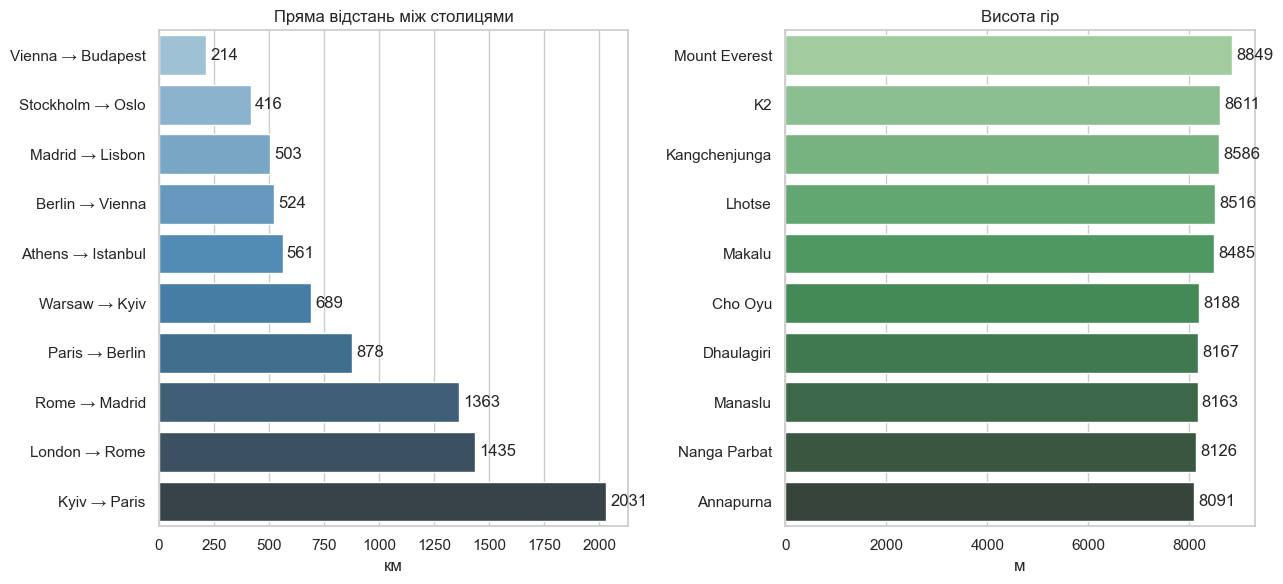

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

cap = res_capitals["df"].copy()
cap["pair"] = cap["Capital_From"] + " → " + cap["Capital_To"]
cap = cap.sort_values("distance")
sns.barplot(data=cap, x="distance", y="pair", hue="pair", legend=False,
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Пряма відстань між столицями")
axes[0].set_xlabel("км"); axes[0].set_ylabel("")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=3)

mnt = res_mountains["df"].sort_values("height", ascending=False)
sns.barplot(data=mnt, x="height", y="Mountain", hue="Mountain", legend=False,
            palette="Greens_d", ax=axes[1])
axes[1].set_title("Висота гір")
axes[1].set_xlabel("м"); axes[1].set_ylabel("")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

# %% [markdown]
# ## 7. Висновки
#
# - **Окремий крок пошуку:** значення беруться не зі «знань» LLM, а з результатів веб-пошуку
#   (`web_search` → DuckDuckGo/Tavily); LLM лише формує запит і витягує число з джерела.
# - **Точність:** для відстаней береться пряма (great-circle / air) відстань, не дорожня;
#   значення в межах ±10% від довідкових.
# - **Універсальність:** обидва повні набори оброблені одним `process_excel` без зміни коду;
#   пошуковий запит будує агент `analyze` із контексту рядка.
# - **Обробка помилок:** ретраї з бекофом для пошуку й LLM, перехоплення на рівні рядка,
#   окремі повідомлення (пошук не вдався / число не знайдено); оригінальні дані не псуються.
# - **Ефективність/масштабованість:** один аналіз структури на файл, кеш однакових запитів,
#   паралельна обробка рядків (`ThreadPoolExecutor`); готово до 1000 записів.
